# Proyecto de Grado: IA al servicio de las comunidades
Maestría en Analítica para la Inteligencia de Negocios

**Nombres:** María Fernanda Izquierdo Aparicio & Ana María Ochoa Muñoz

**Fecha:** 7 de Abril de 2025

Este modelo forma parte del proyecto de grado de la Maestría en Analítica para la Inteligencia de Negocios de la Pontificia Universidad Javeriana, enfocado en la aplicación de Inteligencia Artificial al servicio de las comunidades. Su objetivo es clasificar imágenes de plantas en función de su especie.

## 1. Importe de librerias

Se cargan las librerías necesarias para manipulación de datos, procesamiento de imágenes y modelado con redes neuronales. Algunas destacadas:

* Pandas y NumPy: Para manejo de datos.
* Matplotlib y Seaborn: Para visualización.
* OpenCV (cv2) y PIL (Image): Para procesamiento de imágenes.
* TensorFlow y Keras: Para construir y entrenar modelos de deep learning.

In [3]:
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import os
import zipfile
import shutil
import seaborn as sns
import datetime
import cv2


import keras
from keras import models
from keras import layers

import random

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras import Layer
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam


from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

from PIL import Image  # Librería para abrir y manipular imágenes

# ignoring warnings
import warnings
warnings.simplefilter("ignore")

In [4]:
#Medir_tiempo_ejecucion():
inicio = datetime.datetime.now()
print(f"Inicio: {inicio.strftime('%Y-%m-%d %H:%M:%S.%f')}")

Inicio: 2025-04-07 13:06:55.930298


## 2. Importe de Datos
* Se importa un archivo CSV (Data_Final.csv) con el listado de imágenes y etiquetas.
* Se eliminan registros de la clase "Orange".
* Se divide el dataset en 80% entrenamiento - 20% prueba, asegurando balance entre clases con stratify.

In [6]:
data=pd.read_csv('Metadatos_Finales.csv', sep=";")
data.head()

,Dataset,Carpeta,Nombre del archivo,Planta,Condición,Saludable,Planta_Estado
0,Cassava Leaf Disease Classification,Cassava,1000015157.jpg,Yuca,Cassava Bacterial Blight (CBB),No,Yuca_sick
1,Cassava Leaf Disease Classification,Cassava,1000201771.jpg,Yuca,Cassava Mosaic Disease (CMD),No,Yuca_sick
2,Cassava Leaf Disease Classification,Cassava,100042118.jpg,Yuca,Cassava Brown Streak Disease (CBSD),No,Yuca_sick
3,Cassava Leaf Disease Classification,Cassava,1000723321.jpg,Yuca,Cassava Brown Streak Disease (CBSD),No,Yuca_sick
4,Cassava Leaf Disease Classification,Cassava,1000812911.jpg,Yuca,Cassava Mosaic Disease (CMD),No,Yuca_sick


In [7]:
data = data[data["Planta"] != "Orange"]
data = data[data["Planta"] != "Grape"]
data = data[data["Planta"] != "Pepper_bell"]
data = data[data["Planta"] != "Peach"]

## 3. Análisis de Datos y Creación de conjuntos de train & test

* Se analiza la distribución de imágenes por categoría mediante gráficos de conteo.
Se visualizan imágenes de plantas saludables y enfermas usando OpenCV.

Se obtiene el tamaño de las imágenes para estandarizar el preprocesamiento.

### 3.1. Conteo de imágenes por categoría Plantas (Especies)

In [10]:
data.Planta.value_counts()

Planta
Yuca            21397
Tomato          18160
Corn_(maize)     3852
Apple            3174
Potato           2152
Strawberry       1565
bean             1296
cucumber          691
cauliflower       656
Name: count, dtype: int64

### 3.2. Division aleatoria entre conjunto de train y test usando una dividion 80% - 20%

In [12]:
train, test= train_test_split(data, test_size=0.2, random_state=42,shuffle=True, stratify=data['Planta'])
train.shape, test.shape

((42354, 7), (10589, 7))

### 3.3. Conteo de imágenes por en el conjunto train por categoría

In [14]:
data.Planta.value_counts()

Planta
Yuca            21397
Tomato          18160
Corn_(maize)     3852
Apple            3174
Potato           2152
Strawberry       1565
bean             1296
cucumber          691
cauliflower       656
Name: count, dtype: int64

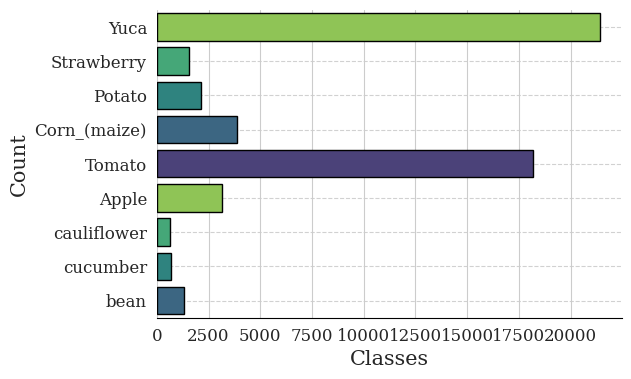

In [15]:
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize = (6, 4))

for i in ['top', 'right', 'left']:
    ax.spines[i].set_visible(False)
ax.spines['bottom'].set_color('black')

sns.countplot(data.Planta, edgecolor = 'black',
              palette = reversed(sns.color_palette("viridis", 5)))
plt.xlabel('Classes', fontfamily = 'serif', size = 15)
plt.ylabel('Count', fontfamily = 'serif', size = 15)
plt.xticks(fontfamily = 'serif', size = 12)
plt.yticks(fontfamily = 'serif', size = 12)
ax.grid(axis = 'y', linestyle = '--', alpha = 0.9)
plt.show()

### 3.4. Conteo de imágenes por en el conjunto test por categoría

In [17]:
data.Planta.value_counts()

Planta
Yuca            21397
Tomato          18160
Corn_(maize)     3852
Apple            3174
Potato           2152
Strawberry       1565
bean             1296
cucumber          691
cauliflower       656
Name: count, dtype: int64

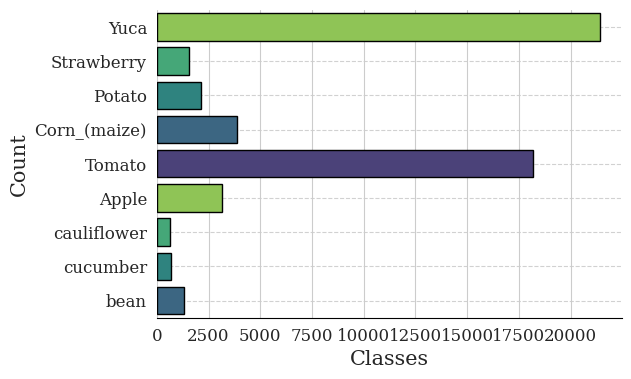

In [18]:
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize = (6, 4))

for i in ['top', 'right', 'left']:
    ax.spines[i].set_visible(False)
ax.spines['bottom'].set_color('black')

sns.countplot(data.Planta, edgecolor = 'black',
              palette = reversed(sns.color_palette("viridis", 5)))
plt.xlabel('Classes', fontfamily = 'serif', size = 15)
plt.ylabel('Count', fontfamily = 'serif', size = 15)
plt.xticks(fontfamily = 'serif', size = 12)
plt.yticks(fontfamily = 'serif', size = 12)
ax.grid(axis = 'y', linestyle = '--', alpha = 0.9)
plt.show()

### 3.5. Muestra de Imagenes

In [20]:
# Cambiar el nombre de la columna
test = test.rename(columns={'Nombre del archivo': 'image_id'})
train = train.rename(columns={'Nombre del archivo': 'image_id'})

In [21]:
train.head()

,Dataset,Carpeta,image_id,Planta,Condición,Saludable,Planta_Estado
1580,Cassava Leaf Disease Classification,Cassava,1277648239.jpg,Yuca,Cassava Mosaic Disease (CMD),No,Yuca_sick
52778,PlantVillage,Apple___Apple_scab,3c27bbd7-b305-4ab0-8a85-5061363cf632___FREC_Sc...,Apple,Apple_scab,No,Apple_sick
45528,PlantVillage,Tomato___healthy,87f08e15-5b2d-4d01-b83b-fd958eba02d4___GH_HL L...,Tomato,healthy,Si,Tomato_healthy
53045,PlantVillage,Corn_(maize)___Northern_Leaf_Blight,acfc653f-44e2-41f6-85cd-3595a6fd7455___RS_NLB ...,Corn_(maize),Northern_Leaf_Blight,No,Corn_(maize)_sick
48231,PlantVillage,Tomato___Tomato_Yellow_Leaf_Curl_Virus,2e90eb55-3401-4132-9f57-b4a46ed27e67___UF.GRC_...,Tomato,Tomato_Yellow_Leaf_Curl_Virus,No,Tomato_sick


#### Plantas Healthy

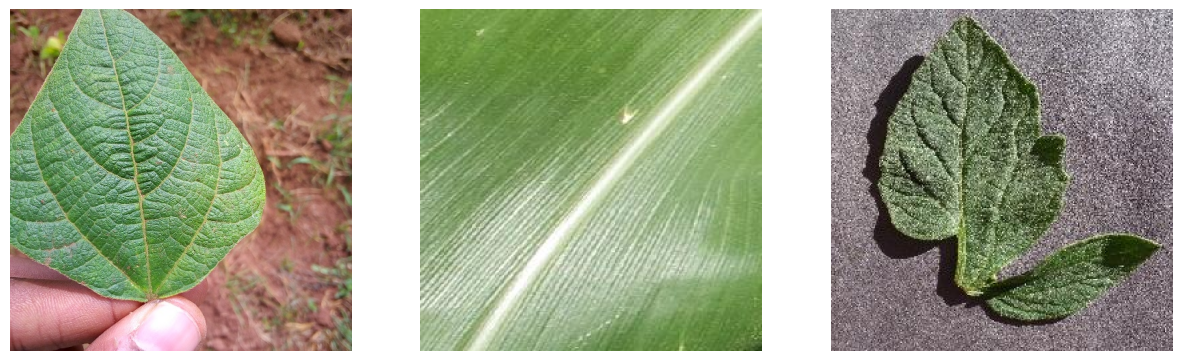

In [23]:
# Seleccionar 3 muestras de la clase "Healthy"
sample = train[train.Saludable == "Si"].sample(3)

# Tamaño de la figura
plt.figure(figsize=(15, 5))

# Carpeta donde están las imágenes
image_folder = "Datos Finales"

for ind, (image_id, Planta) in enumerate(zip(sample.image_id, sample.Planta)):
    plt.subplot(1, 3, ind + 1)

    # Construir la ruta completa de la imagen
    image_path = os.path.join(image_folder, image_id)

    # Cargar la imagen correctamente
    img = cv2.imread(image_path)

    # Verificar si la imagen se cargó correctamente
    if img is None:
        print(f"Error al cargar la imagen: {image_path}")
        continue

    # Convertir la imagen de BGR a RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Mostrar la imagen
    plt.imshow(img)
    plt.axis("off")

plt.show()

#### Plantas con alguna enfermedad

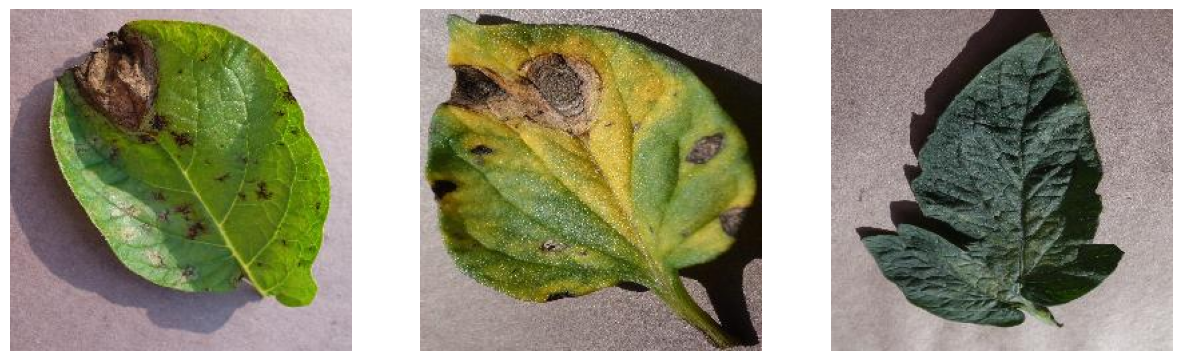

In [25]:
# Seleccionar 3 muestras de la clase "Healthy"
sample = train[train.Saludable == "No"].sample(3)

# Tamaño de la figura
plt.figure(figsize=(15, 5))

# Carpeta donde están las imágenes
image_folder = "Datos Finales"

for ind, (image_id, Planta) in enumerate(zip(sample.image_id, sample.Planta)):
    plt.subplot(1, 3, ind + 1)

    # Construir la ruta completa de la imagen
    image_path = os.path.join(image_folder, image_id)

    # Cargar la imagen correctamente
    img = cv2.imread(image_path)

    # Verificar si la imagen se cargó correctamente
    if img is None:
        print(f"Error al cargar la imagen: {image_path}")
        continue

    # Convertir la imagen de BGR a RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Mostrar la imagen
    plt.imshow(img)
    plt.axis("off")

plt.show()

Obtener el tamaño de las imágenes

In [27]:
image_path = os.path.join(image_folder, image_id)

# Definir la carpeta con las imágenes
image_folder = "Datos Finales"

# Función para obtener el tamaño de una imagen
def get_image_size(image_path):
    try:
        with Image.open(image_path) as img:
            return img.size  # Devuelve (ancho, alto)
    except Exception as e:
        print(f"Error con la imagen {image_path}: {e}")
        return None, None

In [28]:
# Obtener el tamaño de cada imagen y agregarlo al DataFrame
widths = []
heights = []

for img_name in train["image_id"]:  # Asegúrate de que la columna se llama "image_id"
    img_path = os.path.join(image_folder, img_name)
    width, height = get_image_size(img_path)
    widths.append(width)
    heights.append(height)

train["width"] = widths
train["height"] = heights

# Mostrar las primeras filas con los nuevos datos
print(train.head())

Error con la imagen Datos Finales/archivos_plantvillage.csv: cannot identify image file '/Users/mfia/Documents/MFIA - PUJ - Maestría/Proyecto de Grado/0. Data/Datos Finales/archivos_plantvillage.csv'
Error con la imagen Datos Finales/Untitled.ipynb: [Errno 2] No such file or directory: '/Users/mfia/Documents/MFIA - PUJ - Maestría/Proyecto de Grado/0. Data/Datos Finales/Untitled.ipynb'
Error con la imagen Datos Finales/.ipynb_checkpoints: [Errno 2] No such file or directory: '/Users/mfia/Documents/MFIA - PUJ - Maestría/Proyecto de Grado/0. Data/Datos Finales/.ipynb_checkpoints'
Error con la imagen Datos Finales/bean_healthy_train.120tore: cannot identify image file '/Users/mfia/Documents/MFIA - PUJ - Maestría/Proyecto de Grado/0. Data/Datos Finales/bean_healthy_train.120tore'
                                    Dataset  \
1580   Cassava Leaf Disease Classification    
52778                          PlantVillage   
45528                          PlantVillage   
53045                 

## 4. Preparación del Modelo

* Se implementará data augmentation para mejorar la generalización.
* Se evaluará el modelo con métricas como precisión y recall.

In [30]:
# Hiperparámetros principales
BATCH_SIZE = 32
STEPS_PER_EPOCH = len(train)*0.8 / BATCH_SIZE
VALIDATION_STEPS = len(train)*0.2 / BATCH_SIZE
EPOCHS = 20
TARGET_SIZE = 150

In [31]:
train.Planta = train.Planta.astype('str')

train_datagen = ImageDataGenerator(validation_split = 0.2,
                                     preprocessing_function = None,
                                     rotation_range = 45,
                                     zoom_range = 0.2,
                                     horizontal_flip = True,
                                     vertical_flip = True,
                                     fill_mode = 'nearest',
                                     shear_range = 0.1,
                                     height_shift_range = 0.1,
                                     width_shift_range = 0.1)

train_generator = train_datagen.flow_from_dataframe(train,
                         directory = "Datos Finales",
                         subset = "training",
                         x_col = "image_id",
                         y_col = "Planta",
                         target_size = (TARGET_SIZE, TARGET_SIZE),
                         batch_size = BATCH_SIZE,
                         class_mode = "categorical")


validation_datagen = ImageDataGenerator(validation_split = 0.2)

validation_generator = validation_datagen.flow_from_dataframe(train,
                         directory = "Datos Finales",
                         subset = "validation",
                         x_col = "image_id",
                         y_col = "Planta",
                         target_size = (TARGET_SIZE, TARGET_SIZE),
                         batch_size = BATCH_SIZE,
                         class_mode = "categorical")

Found 33880 validated image filenames belonging to 9 classes.
Found 8470 validated image filenames belonging to 9 classes.


Imágen Aleatoria antes de Augmentation

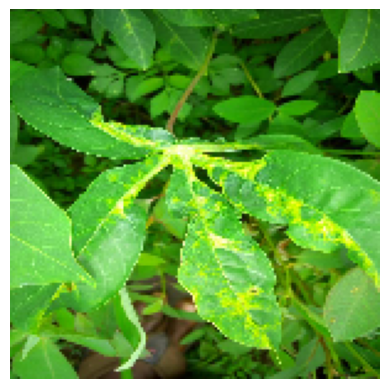

In [33]:
img_path = os.path.join("Datos Finales", train.image_id[20])
img = image.load_img(img_path, target_size = (TARGET_SIZE, TARGET_SIZE))
img_tensor = image.img_to_array(img)
img_tensor = np.expand_dims(img_tensor, axis = 0)
img_tensor /= 255.

plt.imshow(img_tensor[0])
plt.axis('off')
plt.show()

In [34]:
generator = train_datagen.flow_from_dataframe(train.iloc[20:21],
                         directory = "Datos Finales",
                         x_col = "image_id",
                         y_col = "Planta",
                         target_size = (TARGET_SIZE, TARGET_SIZE),
                         batch_size = BATCH_SIZE,
                         class_mode = "categorical")

aug_images = [generator[0][0][0]/255 for i in range(10)]
fig, axes = plt.subplots(2, 5, figsize = (TARGET_SIZE, TARGET_SIZE))
axes = axes.flatten()
for img, ax in zip(aug_images, axes):
    ax.imshow(img)
    ax.axis('off')
plt.tight_layout()
plt.show()

Found 1 validated image filenames belonging to 1 classes.


In [35]:
# Cargar la imagen original
img_path = os.path.join("Datos Finales", train.image_id[20])
img = image.load_img(img_path, target_size = (TARGET_SIZE, TARGET_SIZE))
img_tensor = image.img_to_array(img) / 255.0  # Normalizamos aquí mismo

# Generador con aumentación
generator = train_datagen.flow_from_dataframe(train.iloc[20:21],
                         directory = "Datos Finales",
                         x_col = "image_id",
                         y_col = "Planta",
                         target_size = (TARGET_SIZE, TARGET_SIZE),
                         batch_size = BATCH_SIZE,
                         class_mode = "categorical")

# Lista con la imagen original + 9 imágenes aumentadas
aug_images = [img_tensor] + [generator[0][0][0]/255.0 for i in range(9)]

# Mostrar las 10 imágenes (1 original + 9 aumentadas)
fig, axes = plt.subplots(2, 5, figsize=(TARGET_SIZE, TARGET_SIZE))
axes = axes.flatten()
for img, ax in zip(aug_images, axes):
    ax.imshow(img)
    ax.axis('off')
plt.tight_layout()
plt.show()


Found 1 validated image filenames belonging to 1 classes.


In [36]:
file_name = train.image_id[20]
print(file_name)

1004105566.jpg


## 5. Construcción del Modelo

### 5.1. Clasificador

**Arquitectura del Modelo CNN**
El modelo es una red neuronal convolucional (**CNN**) diseñada para clasificar imágenes de plantas en distintas categorías. Su arquitectura incluye:

**1. Capas Convolucionales y de MaxPooling**
Cada capa convolucional extrae características de las imágenes, mientras que **MaxPooling** reduce la dimensionalidad, mejorando la eficiencia del modelo.

- **Capa 1:**  
  - `Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3))`  
  - `BatchNormalization()`
  - `MaxPooling2D(2,2)`

- **Capa 2:**  
  - `Conv2D(64, (3,3), activation='relu')`  
  - `BatchNormalization()`
  - `MaxPooling2D(2,2)`

- **Capa 3:**  
  - `Conv2D(128, (3,3), activation='relu')`  
  - `BatchNormalization()`
  - `MaxPooling2D(2,2)`

- **Capa 4:**  
  - `Conv2D(128, (3,3), activation='relu')`  
  - `BatchNormalization()`
  - `MaxPooling2D(2,2)`

**2. Capa de Aplanamiento**
Después de las capas convolucionales, se usa `Flatten()` para convertir la salida en un vector de una dimensión.

**3. Capas Densas y Regularización**
- Una capa densa con **512 neuronas** y función de activación ReLU.
- Se usa **Dropout (0.5)** para reducir el sobreajuste.
  
**4. Capa de Salida**
- `Dense(9, activation='softmax')`  
- La activación **softmax** se usa porque se trata de un problema de clasificación multiclase (9 categorías).

In [39]:
# Arquitectura del modelo CNN
model = models.Sequential()

# Capa 1: Convolucional y MaxPooling
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(2, 2))

# Capa 2: Convolucional y MaxPooling
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(2, 2))

# Capa 3: Convolucional y MaxPooling
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(2, 2))

# Capa 4: Convolucional y MaxPooling
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(2, 2))

# Aplanamiento de la capa convolucional
model.add(layers.Flatten())

# Clasificador
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dropout(0.5))  # Dropout para evitar el overfitting

# Capa de salida
model.add(layers.Dense(9, activation='softmax'))  

### 5.2. Compilación del modelo

In [41]:
model.compile(
    loss='categorical_crossentropy',  # Cambiado a 'categorical_crossentropy' para múltiples clases
    optimizer='adam',
    metrics=['accuracy']
)

In [42]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 15, 15, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         4,617 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,458,633 (13.19 MB)

 Trainable params: 3,457,929 (13.19 MB)

 Non-trainable params: 704 (2.75 KB)

## 6. Ejecución del modelo

* Se entrenará el modelo utilizando Adam como optimizador y EarlyStopping para prevenir sobreajuste.
* Se evaluará el desempeño sobre el conjunto de prueba.

In [44]:
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor the validation loss
    patience=5,  # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True  # Restore the model weights from the epoch with the best value of the monitored quantity
)

from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,  # Reduce learning rate by a factor of 0.2
    patience=3,  # Number of epochs with no improvement after which learning rate will be reduced
    min_lr=1e-5  # Minimum learning rate
)

In [45]:
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    callbacks=[early_stopping, reduce_lr],
    verbose=2
)

Epoch 1/20
1059/1059 - 704s - 665ms/step - accuracy: 0.7971 - loss: 0.7589 - val_accuracy: 0.5970 - val_loss: 1.2727 - learning_rate: 0.0010
Epoch 2/20
1059/1059 - 1204s - 1s/step - accuracy: 0.8624 - loss: 0.4277 - val_accuracy: 0.8672 - val_loss: 0.4360 - learning_rate: 0.0010
Epoch 3/20



KeyboardInterrupt



### 6.1. Resultados del Modelo

In [ ]:
# Acceder a los datos de pérdida y precisión
loss = history.history['loss']
val_loss = history.history['val_loss']
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Graficar la pérdida del modelo
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Graficar la precisión del modelo
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

In [ ]:
epochs = [1, 2, 3, 4, 5, 6, 7, 8]
data = {
    'Epoch': epochs,
    'Trainning Loss': loss,
    'Validation Loss': val_loss,
    'Training Accuracy': accuracy,
    'Validation  Accuracy': val_accuracy
}
df = pd.DataFrame(data)

# Imprimir la tabla
print(df)

In [ ]:
# Accuracy final en entrenamiento
val_loss = history.history['val_loss'][-1]

In [ ]:
print('Perdida final en Train:', history.history['loss'][-1])
print("Pérdida final en Validation:", history.history['val_loss'][-1])


print("Accuracy final en Train:", history.history['accuracy'][-1])
print("Accuracy final en Validation:", history.history['val_accuracy'][-1])

## 7. Evaluación del Modelo

### 7.1. Lote de imagenes de testeo

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

In [ ]:
fin = datetime.datetime.now()
print(f"Fin: {fin.strftime('%Y-%m-%d %H:%M:%S.%f')}")
    
duracion = fin - inicio
print(f"Duración: {duracion}")

In [ ]:
test.Planta = test.Planta.astype('str')

test_generator =  train_datagen.flow_from_dataframe(test,
                         directory = "Datos Finales",
                         subset = "training",
                         x_col = "image_id",
                         y_col = "Planta",
                         target_size = (TARGET_SIZE, TARGET_SIZE),
                         batch_size = BATCH_SIZE,
                         class_mode = "categorical")

### 7.2. Predicciones con imagenes de Testeo

In [ ]:
# -------------------------
# 1. Obtener predicciones completas para test
# -------------------------
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

In [ ]:
# -------------------------
# 2. Matriz de Confusión
# -------------------------
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_generator.class_indices.keys())
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de Confusión - Test")
plt.show()


### 7.3. Presición de la Predicción

In [ ]:
accuracy = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

### 7.4. Muestreo visual de predicciones vs etiquetas reales


In [ ]:
# Función para normalizar imágenes solo para visualización
def normalize_for_display(img):
    img_min = img.min()
    img_max = img.max()
    if img_max > 1.0 or img_min < 0.0:
        img = (img - img_min) / (img_max - img_min + 1e-7)
    return img

# Obtener nombres de clases
class_indices = test_generator.class_indices
class_names = list(class_indices.keys())

# Reiniciar el generador para empezar desde el principio
test_generator.reset()
x_batch, y_true_batch = next(test_generator)

# Obtener predicciones del modelo
y_pred_probs_batch = model.predict(x_batch)
y_pred_batch = np.argmax(y_pred_probs_batch, axis=1)
y_true_batch = np.argmax(y_true_batch, axis=1)

# Número de imágenes a mostrar (máximo el tamaño del batch)
num_samples = x_batch.shape[0]

# Mostrar imágenes con etiquetas
plt.figure(figsize=(15, 8))
for i in range(num_samples):
    plt.subplot(3, 4, i + 1)
    img_to_show = normalize_for_display(x_batch[i])
    plt.imshow(img_to_show)
    plt.axis('off')
    plt.title(
        f"Real: {class_names[y_true_batch[i]]}\nPred: {class_names[y_pred_batch[i]]}",
        color='green' if y_true_batch[i] == y_pred_batch[i] else 'red'
    )
plt.tight_layout()
plt.suptitle("Muestreo de Predicciones vs. Etiquetas Reales", fontsize=16, y=1.02)
plt.show()

In [ ]:
# Función para normalizar imágenes solo para visualización
def normalize_for_display(img):
    img_min = img.min()
    img_max = img.max()
    if img_max > 1.0 or img_min < 0.0:
        img = (img - img_min) / (img_max - img_min + 1e-7)
    return img

# Obtener nombres de clases
class_indices = test_generator.class_indices
class_names = list(class_indices.keys())

# Reiniciar el generador para empezar desde el principio
test_generator.reset()
x_batch, y_true_batch = next(test_generator)

# Obtener predicciones del modelo
y_pred_probs_batch = model.predict(x_batch)
y_pred_batch = np.argmax(y_pred_probs_batch, axis=1)
y_true_batch = np.argmax(y_true_batch, axis=1)

# Número de imágenes a mostrar (máximo el tamaño del batch)
num_samples = x_batch.shape[0]

# Mostrar imágenes con etiquetas
plt.figure(figsize=(15, 8))
for i in range(num_samples):
    plt.subplot(3, 4, i + 1)
    img_to_show = normalize_for_display(x_batch[i])
    plt.imshow(img_to_show)
    plt.axis('off')
    plt.title(
        f"Real: {class_names[y_true_batch[i]]}\nPred: {class_names[y_pred_batch[i]]}",
        color='green' if y_true_batch[i] == y_pred_batch[i] else 'red'
    )
plt.tight_layout()
plt.suptitle("Muestreo de Predicciones vs. Etiquetas Reales", fontsize=16, y=1.02)
plt.show()

### 7.5. Curva ROC

In [ ]:
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.utils import to_categorical

# 3. Convertir etiquetas reales a one-hot
n_classes = y_pred_probs.shape[1]
y_true_onehot = to_categorical(y_true, num_classes=n_classes)

# 4. Calcular ROC y AUC por clase
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 5. Obtener nombres de clase
class_names = list(test_generator.class_indices.keys())

# 6. Graficar curvas ROC
plt.figure(figsize=(12, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC por clase')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score

# AUC macro (promedio de clases, todas igual de importantes)
auc_macro = roc_auc_score(y_true_onehot, y_pred_probs, average='macro')

# AUC micro (promedia sobre todas las instancias)
auc_micro = roc_auc_score(y_true_onehot, y_pred_probs, average='micro')

print(f"AUC Macro promedio: {auc_macro:.4f}")
print(f"AUC Micro promedio: {auc_micro:.4f}")


In [ ]:
epochs_ = list(range(1, EPOCHS + 1))
print(epochs_)

### 7.6. Resultado de la Evaluación del Modelo

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Asegúrate de tener esto:
# y_pred = np.argmax(y_pred_probs, axis=1)
# y_true = test_generator.classes

# Accuracy
accuracy = accuracy_score(y_true, y_pred)

# F1 Scores
f1_macro = f1_score(y_true, y_pred, average='macro')
f1_micro = f1_score(y_true, y_pred, average='micro')
f1_weighted = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score (macro): {f1_macro:.4f}")
print(f"F1 Score (micro): {f1_micro:.4f}")
print(f"F1 Score (weighted): {f1_weighted:.4f}")

# Detalle por clase
class_names = list(test_generator.class_indices.keys())
print("\nReporte de clasificación por clase:")
print(classification_report(y_true, y_pred, target_names=class_names))
